In [3]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np

/Users/dominik/programming_uni/informationssysteme_2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Daten laden und analysieren

In [4]:
df = pd.read_csv(os.path.join('toxic_comments_de.csv'))

In [181]:
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,"""\n\n NPOV wieder\n\nZunächst einmal bin ich B...",0,0,0,0,0,0
1,Ich habe gerade eine auf meiner Benutzerseite ...,0,0,0,0,0,0
2,Dein Name ist ich träume von Pferden was für e...,1,0,1,0,1,0
3,"""\n\n mehr NPOV-Probleme\n\nDieser Artikel ist...",0,0,0,0,0,0
4,"""\n Wir behaupten nie, dass es ein """"Sexspiel""...",0,0,0,0,0,0


In [182]:
df.tail()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
148640,"""\n\nCool. Ich weiß, was Sie mit Bearbeitungen...",0,0,0,0,0,0
148641,Billy H\n\nIch habe Ihren RFC über Billy Hatho...,0,0,0,0,0,0
148642,Danke vielmals! Können die von mir angegebenen...,0,0,0,0,0,0
148643,Kann ich also den Fehler im Artikel korrigiere...,0,0,0,0,0,0
148644,"Ich habe eine Quelle angegeben, du verdammter ...",1,0,1,0,1,0


In [5]:
df.iloc[148544]['comment_text']
df.iloc[148544][1:]

toxic            1
severe_toxic     1
obscene          1
threat           0
insult           1
identity_hate    0
Name: 148544, dtype: object

In [ ]:
# für jedes Label die Summe an Vorkommnissen (1er) ermitteln
labels = df.columns[1:]
counts = df[labels].sum().sort_values(ascending=False)

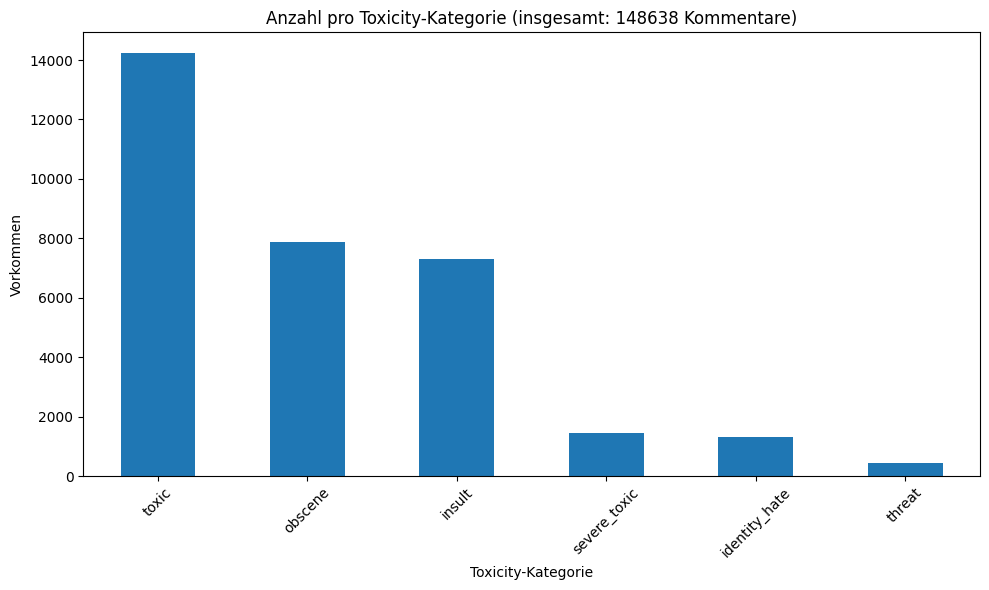

In [ ]:
import matplotlib.pyplot as plt

# Vorkommnisse der einzelnen Labels visualisieren
plt.figure(figsize=(10, 6))
counts.plot(kind='bar')
plt.title('Anzahl pro Toxicity-Kategorie (insgesamt: 148638 Kommentare)')
plt.ylabel('Vorkommen')
plt.xlabel('Toxicity-Kategorie')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


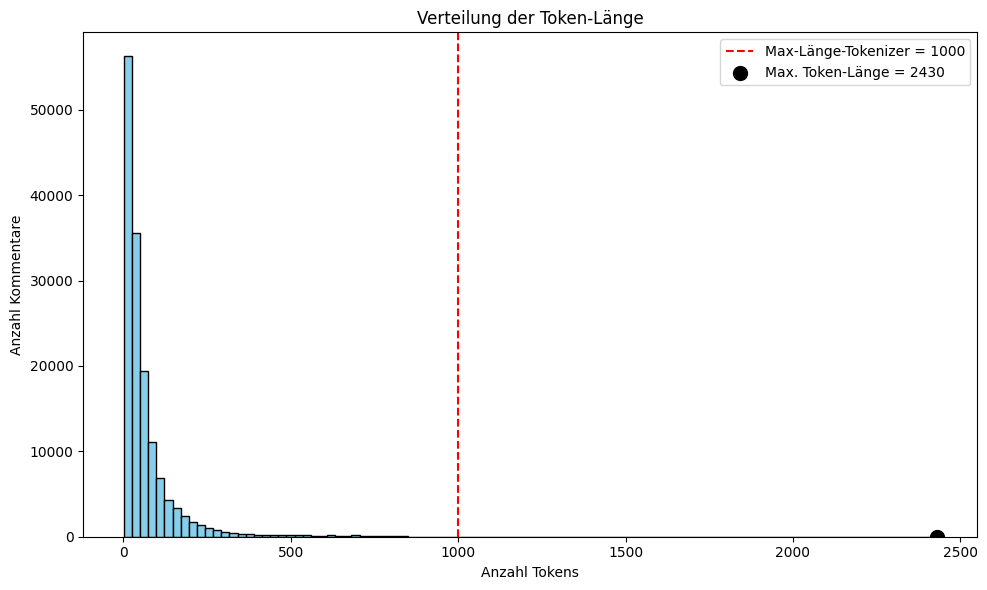

In [186]:
token_lens = [len(text.split()) for text in df['comment_text']]
max_token_len = max(token_lens)
max_length_tokenizer = 1000

plt.figure(figsize=(10, 6))
plt.hist(token_lens, bins=100, color='skyblue', edgecolor='black')

# Roter Strich für maximale output_sequence_length im Vectorizer
plt.axvline(max_length_tokenizer, color='red', linestyle='--', label=f'Max-Länge-Tokenizer = {max_length_tokenizer}')

# Schwarzer Punkt auf der X-Achse größten Kommentar
plt.scatter([max_token_len], [0], color='black', zorder=5, label=f'Max. Token-Länge = {max_token_len}', marker='o', s=100)

plt.title('Verteilung der Token-Länge')
plt.xlabel('Anzahl Tokens')
plt.ylabel('Anzahl Kommentare')
plt.legend()
plt.tight_layout()
plt.show()

## Preprosessing

In [187]:
from tensorflow import keras
from keras.layers import TextVectorization
# Preprosessing layer which maps text features to integer sequences
# Hate -> 42
# Gut -> 13

In [ ]:
X = df['comment_text'] # Alle Kommentare (Input-Features)
y = df[df.columns[1:]].values # Array mit "Vektoren" -> ein Vektor pro Kommentar - Zielwerte

In [ ]:
MAX_FEATURES = 20_0000 # Anzahl der maximal zulässigen Wörter im Vokabular des Vectorizers

In [ ]:
# Text-Vektorisierung: Umwandlung der Kommentare in Integer-Sequenzen
vectorizer = TextVectorization(
    max_tokens=MAX_FEATURES, 
    output_sequence_length=max_length_tokenizer, 
    output_mode='int'
)
# Punctuation und Whitespaces werden entfernt
# Wenn weniger als 1000 Token -> auffüllen mit 0er
# Wenn mehr als 1000 Token -> abschneiten bei 1000

In [ ]:
vectorizer.adapt(X.values) # Vectorizer "lernt" das Vokabular auf Basis der Trainingsdaten

In [201]:
vectorizer.get_vocabulary()

['',
 '[UNK]',
 'die',
 'sie',
 'ich',
 'und',
 'der',
 'zu',
 'ist',
 'es',
 'nicht',
 'dass',
 'in',
 'von',
 'das',
 'auf',
 'eine',
 'ein',
 'den',
 'für',
 'wenn',
 'mit',
 'habe',
 'als',
 'haben',
 'oder',
 'wie',
 'artikel',
 'sind',
 'werden',
 'aber',
 'um',
 'sich',
 'du',
 'was',
 'des',
 'er',
 'hat',
 'einen',
 'dem',
 'auch',
 'an',
 'im',
 'ihre',
 'wird',
 'mich',
 'wikipedia',
 'nur',
 'diese',
 'über',
 'bitte',
 'dies',
 'wurde',
 'mir',
 'war',
 'können',
 'keine',
 'aus',
 'sein',
 'so',
 'wir',
 'kann',
 'seite',
 'dieser',
 'bei',
 'einer',
 'hier',
 'bin',
 'da',
 'einem',
 'meine',
 'nach',
 'noch',
 'gibt',
 'zum',
 'alle',
 'ihnen',
 'warum',
 'sollte',
 'anderen',
 'werde',
 'mehr',
 'andere',
 'immer',
 'weil',
 'würde',
 'also',
 'etwas',
 'vielen',
 'sehr',
 'diesem',
 'dich',
 'diskussionsseite',
 'ihr',
 'informationen',
 'tun',
 'vor',
 'kein',
 'dann',
 'selbst',
 'einige',
 'sagen',
 'zur',
 'dank',
 'jetzt',
 'quellen',
 'einfach',
 'viel',
 'diese

In [210]:
if 'idiot' in vectorizer.get_vocabulary():
    print('Enthalten')
    print(vectorizer('idiot')[:1])

Enthalten
tf.Tensor([382], shape=(1,), dtype=int64)


In [ ]:
vectorizer('Hallo und herzlich wilkommen zu meiner Informationssysteme Präsentation')[:8]

<tf.Tensor: shape=(8,), dtype=int64, numpy=array([   114,      5,    926,  66686,      7,    112, 110258,   6090])>

In [ ]:
vectorized_text = vectorizer(X.values) # Vektorisierung der Kommentare

In [ ]:
vectorized_text # tokenized comments -> int rep von allen Kommentaren

<tf.Tensor: shape=(148645, 1000), dtype=int64, numpy=
array([[ 942,  152, 1366, ...,    0,    0,    0],
       [   4,   22,  279, ...,    0,    0,    0],
       [ 469,  367,    8, ...,    0,    0,    0],
       ...,
       [ 113, 7038,   55, ...,    0,    0,    0],
       [  61,    4,   86, ...,    0,    0,    0],
       [   4,   22,   16, ...,    0,    0,    0]])>

In [219]:
vectorized_array = vectorized_text.numpy().flatten()
vectorized_array_actuall_tokens = [t for t in vectorized_array if t != 0]
vectorized_array_unks = [t for t in vectorized_array if t == 1]

In [220]:
print(f"Anzahl aller Tokens: {len(vectorized_array_actuall_tokens)}")
print(f"Anzahl der [UNK]-Tokens: {len(vectorized_array_unks)}")
unk_ratio = len(vectorized_array_unks) / len(vectorized_array_actuall_tokens)
print(f"Anteil [UNK]: {unk_ratio:.2%}")

Anzahl aller Tokens: 9639488
Anzahl der [UNK]-Tokens: 146024
Anteil [UNK]: 1.51%


In [ ]:
from sklearn.model_selection import train_test_split

# Daten in Train (~70%), Val (~20%) und Test (~10%) splitten
X_train, X_temp, y_train, y_temp = train_test_split(vectorized_text.numpy(), y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42)

In [ ]:
# tf data pipelines bauen für train und val
BATCH_SIZE = 16
BUFFER_SIZE = len(X_train)  # für Shuffle

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(BUFFER_SIZE, reshuffle_each_iteration=True) \
    .batch(BATCH_SIZE) \
    .prefetch(8)

# .shuffle() - zufälliges mischen der train daten bei jeder neuen epoch
# -> ohne shuffle würde Modell immer die gleiche Reihenfolge lernen

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .batch(BATCH_SIZE) \
    .prefetch(8)

# .prefetch(8) - lädt im Hintergrund bis zu 8 Batches während Modell noch mit aktuellem Batch beschäftigt ist

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .batch(BATCH_SIZE)

# .batch(16) - teilt Daten in Batches mit jeweils 16 Elementen

In [ ]:
train_ds.as_numpy_iterator().next() # -> 16 comments mit den 16 passenden lables

(array([[143868,    539,    273, ...,      0,      0,      0],
        [     4,     61,     56, ...,      0,      0,      0],
        [    78,    871,     29, ...,      0,      0,      0],
        ...,
        [  8029,   3319,    145, ...,      0,      0,      0],
        [   549,  11118,      8, ...,      0,      0,      0],
        [   289,     14,   1350, ...,      0,      0,      0]]),
 array([[0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0]]))

## Erstellen und trainieren des DeepLearning NLP Models

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Bidirectional, Dense, Embedding

In [ ]:
model = Sequential() # Sequential Api - Model Schicht für Schicht aufbauen

# Create embedding layer 
model.add(Embedding(MAX_FEATURES+1, 32)) # -> jedes einzelne Wort hat 32 Features 

# Create Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(32, activation='tanh')))

# Feature extractor Fully connected layers

model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))

# Final layer 
model.add(Dense(6, activation='sigmoid')) # 6 Neuronen -> 6 verschiedene Toxicity-Labels durch sigmoid Werte zwischen 0 und 1

In [ ]:
model.compile(loss='BinaryCrossentropy', optimizer='Adam') 

In [162]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, None, 32)          8000032   
                                                                 
 bidirectional_2 (Bidirecti  (None, 64)                16640     
 onal)                                                           
                                                                 
 dense_8 (Dense)             (None, 128)               8320      
                                                                 
 dense_9 (Dense)             (None, 256)               33024     
                                                                 
 dense_10 (Dense)            (None, 128)               32896     
                                                                 
 dense_11 (Dense)            (None, 6)                 774       
                                                      

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds) # tatsächliches trainieren des models

Epoch 1/10
6503/6503 [==============================] - 879s 135ms/step - loss: 0.0685 - val_loss: 0.0481
Epoch 2/10
6503/6503 [==============================] - 861s 132ms/step - loss: 0.0498 - val_loss: 0.0417
Epoch 3/10
6503/6503 [==============================] - 857s 132ms/step - loss: 0.0434 - val_loss: 0.0411
Epoch 4/10
6503/6503 [==============================] - 857s 132ms/step - loss: 0.0387 - val_loss: 0.0344
Epoch 5/10
6503/6503 [==============================] - 857s 132ms/step - loss: 0.0335 - val_loss: 0.0298
Epoch 6/10
6503/6503 [==============================] - 2752s 423ms/step - loss: 0.0297 - val_loss: 0.0264
Epoch 7/10
6503/6503 [==============================] - 907s 139ms/step - loss: 0.0264 - val_loss: 0.0217
Epoch 8/10
6503/6503 [==============================] - 857s 132ms/step - loss: 0.0232 - val_loss: 0.0198
Epoch 9/10
6503/6503 [==============================] - 858s 132ms/step - loss: 0.0204 - val_loss: 0.0171
Epoch 10/10
6503/6503 [======================

## Auswerten der Model Performance

**loss**: Wie stark weicht das Modell in der aktuellen Epoche auf den Trainingsdaten von den echten Labels ab?

**val_loss**: Wie stark weicht das Modell auf den Validierungsdaten von den echten Labels ab? 

**precision**: Wie viele der als positiv vorhergesagten Labels waren tatsächlich korrekt?

**recall**: Wie viele der tatsächlich positiven Fälle wurden erkannt?

**accuracy**: Wie oft hat das Modell den korrekten Klassenindex vorhergesagt?

**AUC**: Wie gut kann das Modell zwischen Klassen unterscheiden – unabhängig vom Schwellenwert?

**BinaryAccuracy**: Wie oft hat das Modell richtig gesagt: Ja oder Nein?

<Figure size 800x500 with 0 Axes>

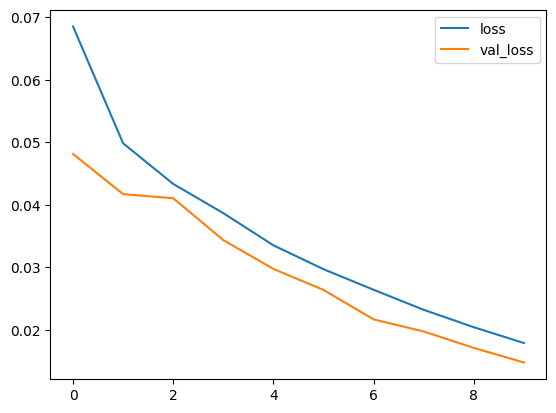

In [165]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8,5))
pd.DataFrame(history.history).plot()
plt.show()

Das Modell zeigt ein zuverlässiges Lernverhalten auf sowohl Trainings- als auch Validierungsdaten.

- Es kann die Trainingsdaten gut vorhersagen (loss sinkt).
- Kann es das Gelernte erfolgreich auf unbekannte Daten übertragen (val_loss sinkt ebenfalls).

=> Das Modell lernt effizient und ohne Anzeichen von Overfitting.

In [229]:
input_text = vectorizer('Ich hasse dich!')

In [230]:
model.predict(np.expand_dims(input_text,0))

1/1 [==============================] - 0s 39ms/step


array([[0.8249431 , 0.00962126, 0.03865877, 0.01995936, 0.6267803 ,
        0.07988337]], dtype=float32)

In [169]:
from keras.metrics import AUC, Precision, Recall, CategoricalAccuracy

In [170]:
pre = Precision()
re = Recall()
acc = CategoricalAccuracy()
auc = AUC()

In [ ]:
for batch in test_ds.as_numpy_iterator(): 
    # Batch unpacken
    X_true, y_true = batch
    # Model Prediction durchführen
    yhat = model.predict(X_true)
    
    # Flatten the predictions -> convert into one big array instead of array of arrays
    y_true = y_true.flatten()
    yhat = yhat.flatten()
    
    pre.update_state(y_true, yhat)
    re.update_state(y_true, yhat)
    acc.update_state(y_true, yhat)
    auc.update_state(y_true, yhat)

1/1 [==============================] - 0s 26ms/step


In [172]:
print(f'Precision: {pre.result().numpy()}, Recall:{re.result().numpy()}, AUC:{auc.result().numpy()}, Accuracy:{acc.result().numpy()}')

Precision: 0.9246996641159058, Recall:0.9446273446083069, AUC:0.9973050355911255, Accuracy:0.4833153784275055


In [238]:
# Für jedes einzelne Label seperat Precision, Recall, AUC, CategorialAccuracy berechnen
# -> Für jedes Label Metrik initialisieren
num_labels = 6
pre_metrics = [Precision(name=f'precision_{i}') for i in range(num_labels)]
rec_metrics = [Recall(name=f'recall_{i}') for i in range(num_labels)]
auc_metrics = [AUC(name=f'auc_{i}') for i in range(num_labels)]

# über Testdaten gehen
for batch in test_ds.as_numpy_iterator():
    # Batch unpacken
    X_true, y_true = batch
    # Model Prediction durchführen
    yhat = model.predict(X_true)

    # Für jede Klasse einzeln updaten
    for i in range(num_labels):
        pre_metrics[i].update_state(y_true[:, i], yhat[:, i])
        rec_metrics[i].update_state(y_true[:, i], yhat[:, i])
        auc_metrics[i].update_state(y_true[:, i], yhat[:, i])

1/1 [==============================] - 0s 19ms/step


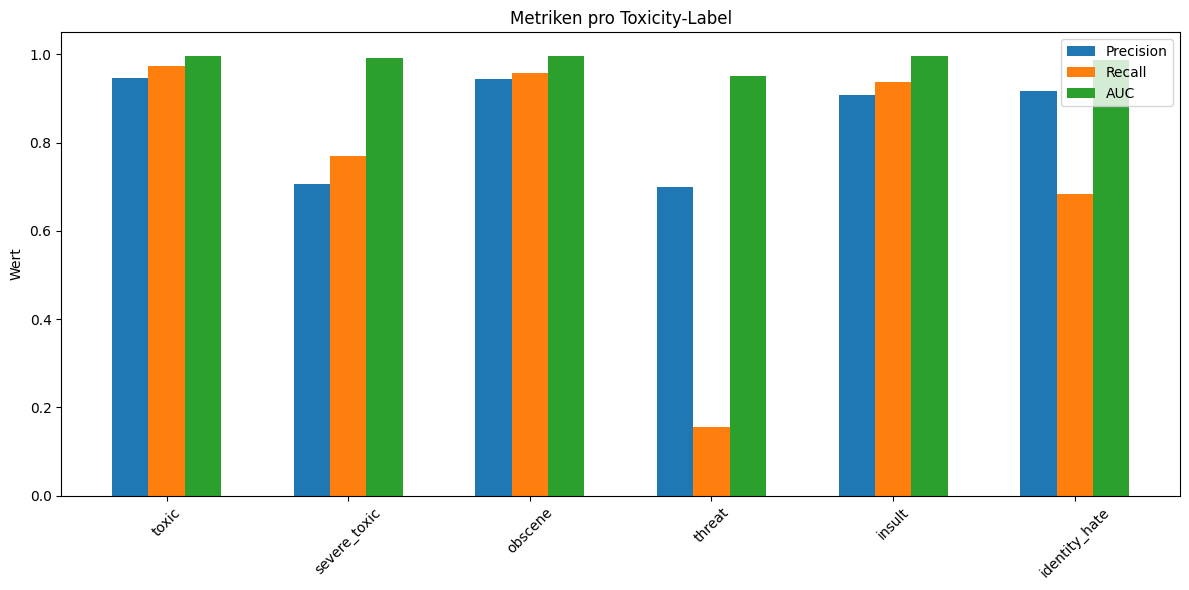

In [239]:
# Liste für jede Metrik mit dem Gesamtergebnis pro Label
precision_vals = [m.result().numpy() for m in pre_metrics]
recall_vals = [m.result().numpy() for m in rec_metrics]
auc_vals = [m.result().numpy() for m in auc_metrics]

# Balkendiagramm zeichnen
x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x, precision_vals, width, label='Precision')
plt.bar(x + width, recall_vals, width, label='Recall')
plt.bar(x + 2*width, auc_vals, width, label='AUC')

plt.xticks(x + width, labels, rotation=45)
plt.ylim(0, 1.05)
plt.ylabel('Wert')
plt.title('Metriken pro Toxicity-Label')
plt.legend()
plt.tight_layout()
plt.show()


## Model speichern

In [ ]:
model.save('toxicity.keras')

In [222]:
import pickle

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)